# Axe 1 : Conditions de travail

Dans ce notebook, j'étudie les variables liées aux facteurs organisationnelles des employés afin d'évaluer leur impact sur l'attrition.

Ce notebook a pour objectif :
- d'explorer les variables de l'axe,
- de comparer avec l'attrition
- d'explorer des relations internes à l’axe
- de visualiser
- retenir seulement ce qui ressort clairement
---

## 1. Exploration des variables de l’axe
---

### 1.1 Import des librairies & chargement des données
---

In [2]:
# import librairies 

import pandas as pd
import pyarrow
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [98]:
# chargement du df
df_clean = pd.read_parquet("C:/Users/Kemu/Documents/Formation/Projet Pro Data/2_Projets_Tests/projet-RH_test/data/processed/employees_clean.parquet")
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   string
 2   BusinessTravel            1470 non-null   string
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   string
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   string
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   string
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

### 1.2 Fonctions utilitaires

In [ ]:
# Tableau de pourcentage variable univarié

def value_counts_percent(serie,round_n=3):

    """  Calcule la distribution (%) d'une variable catégorielle et retourne un DataFrame"""
    
    return (serie.value_counts(normalize=True).
            round(round_n).
            mul(100).
            reset_index(name="Pourcentage"))

# Tableau de pourcentage de variables bivariés
def groupby_percent(df,columns1,columns2,observed=True):
    """Calcule la distribution (%) de columns2 pour chaque modalité de columns1
    et retourne un DataFrame au format long. """
    return(df.groupby(columns1,observed=observed)[columns2].
           value_counts(normalize=True).
           round(2)
           *100).reset_index(name="Pourcentage")

# Table pivot en pourcentage de variables bivarié
def pivot_percent(df,index,columns):
    """ Crée un tableau pivot (%) : lignes=index, colonnes=columns."""
    df = groupby_percent(df,index,columns)
    return(df.pivot(index=index, columns=columns,values="Pourcentage").fillna(0))




### 1.3 Creation du DataFrame Condition de travail
---
#### Colonnes incluses dans l'axe "Condition de travail"

Cet axe regroupe les caractéristiques organisationnelles :
- BusinessTravel = Structure du poste = leger
- Department = Structure du poste = leger mais si gros impact interresant pour l'attrition
- JobLevel = Structure du poste = leger
- JobRole = Structure du poste = detaillé
- MonthlyIncome = Rémunération = detaillé
- OverTime = structure poste = detaillé
- PercentSalaryHike = Rémuneration = leger
- StockOptionLevel = Rémuneration = leger
- TotalWorkingYears = carriere = detaillé
- TrainingTimesLastYear = evolution = 
- YearsAtCompany = ancienneté = detaillé
- YearsInCurrentRole = carriere = detaillé
- YearsSinceLastPromotion = evolution = detaillé
- YearsWithCurrManager = manager = a voir en lien avec departement
 
Ces variables décrivent le contexte organisationnel susceptible d’influencer l’attrition.

In [99]:
# colonnes condition de travail
cols_conditions_travail = ['BusinessTravel', 'Department','JobLevel',"JobRole",'MonthlyIncome','OverTime','PercentSalaryHike','StockOptionLevel',
             "TotalWorkingYears", "TrainingTimesLastYear", "YearsAtCompany","YearsInCurrentRole","YearsSinceLastPromotion","YearsWithCurrManager" ]

# creation df_condition_Trav
df_conditions_travail = df_clean[cols_conditions_travail + ['Attrition']].copy()
df_conditions_travail.head()

,BusinessTravel,Department,JobLevel,JobRole,MonthlyIncome,OverTime,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
0,Travel_Rarely,Sales,2,Sales Executive,5993,Yes,11,0,8,0,6,4,0,5,Yes
1,Travel_Frequently,Research & Development,2,Research Scientist,5130,No,23,1,10,3,10,7,1,7,No
2,Travel_Rarely,Research & Development,1,Laboratory Technician,2090,Yes,15,0,7,3,0,0,0,0,Yes
3,Travel_Frequently,Research & Development,1,Research Scientist,2909,Yes,11,0,8,3,8,7,3,0,No
4,Travel_Rarely,Research & Development,1,Laboratory Technician,3468,No,12,1,6,3,2,2,2,2,No


#### 1.3.1 Préparation des variables
- Renommage pour la lisibilité
- Création de tranches
- Regroupements

##### Renommage des niveaux hiérarchiques (JobLevel)

La variable *JobLevel*, codée de 1 à 5 dans le jeu de données, a été renommée en niveaux hiérarchiques allant de **niveau hiérarchique bas** à **niveau hiérarchique très senior**, afin d’en faciliter l’interprétation.  

Le niveau hiérarchique correspond au niveau du poste occupé et non à l’ancienneté ou à l’expérience totale, comme le montrent certaines observations où des employés de niveau hiérarchique bas présentent plusieurs années d’expérience.  

En l’absence de définition officielle fournie dans la documentation, ce renommage reste volontairement descriptif et neutre.


In [ ]:

joblevel_name = {1 : "Niveau hiérarchique bas",
                2 : "Niveau hiérarchique intermédiaire",
                3 : "Niveau hiérarchique confirmé",
                4 : "Niveau hiérarchique senior",
                5 : "Niveau hiérarchique très senior"}

df_conditions_travail["JobLevel"] = df_conditions_travail["JobLevel"].replace(joblevel_name)
df_conditions_travail.head(2)

##### Création des tranches des revenues mensuelle (MonthlyIncome)

Le revenu mensuel est une variable continue dont la distribution est fortement étalée.  
Afin de faciliter l’analyse et de rendre les résultats plus lisibles d’un point de vue RH, les revenus ont été regroupés en tranches interprétables, basées sur la médiane et sur des seuils cohérents en termes de niveaux de rémunération.

Ces tranches ne visent pas à répartir les effectifs de manière strictement équilibrée, mais à distinguer des profils de rémunération comparables :

- **Faible niveau de rémunération** : < 2 500  
- **Niveau de rémunération intermédiaire bas** : 2 500 – 5 000  
- **Niveau de rémunération intermédiaire haut** : 5 000 – 7 500  
- **Niveau de rémunération élevé** : > 7 500  

Ces tranches permettront d’analyser plus clairement la relation entre le revenu mensuel et l’attrition.

In [102]:
df_conditions_travail["Tranche_Salaire"]= pd.cut(
        df_conditions_travail["MonthlyIncome"],
        bins=[0, 2500, 5000, 7500, 20000],
        labels=["< 2 500", "2 500 - 5 000", "5 000 - 7 500" , "> 7 500"],
        ordered=True,
        include_lowest=True)
df_conditions_travail.head(2)

,BusinessTravel,Department,JobLevel,JobRole,MonthlyIncome,OverTime,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,Tranche_Salaire
0,Travel_Rarely,Sales,Niveau hiérarchique intermédiaire,Sales Executive,5993,Yes,11,0,8,0,6,4,0,5,Yes,5 000 - 7 500
1,Travel_Frequently,Research & Development,Niveau hiérarchique intermédiaire,Research Scientist,5130,No,23,1,10,3,10,7,1,7,No,5 000 - 7 500


##### Création des tranches du pourcentage d’augmentation de salaire (PercentSalaryHike)

Pour faciliter l’analyse exploratoire et rendre les visualisations plus lisibles, le pourcentage d’augmentation de salaire a été regroupé en tranches cohérentes :

- **Faible niveau d’augmentation de salaire** : < 12  
- **Niveau d’augmentation de salaire intermédiaire** : 12 – 15  
- **Niveau d’augmentation de salaire intermédiaire haut** : 15 – 18  
- **Niveau d’augmentation de salaire élevé** : > 18  

Ces catégories permettent d’identifier plus facilement d’éventuelles relations entre le pourcentage d’augmentation de salaire et l’attrition.


In [103]:
df_conditions_travail["Tranche_PercentSalaryHike"]= pd.cut(
        df_conditions_travail["PercentSalaryHike"],
        bins=[0, 12, 15, 18, 30],
        labels=["< 12", "12-15", "15-18", "> 18"],
        ordered=True,
        include_lowest=True)

df_conditions_travail.head(2)

,BusinessTravel,Department,JobLevel,JobRole,MonthlyIncome,OverTime,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,Tranche_Salaire,Tranche_PercentSalaryHike
0,Travel_Rarely,Sales,Niveau hiérarchique intermédiaire,Sales Executive,5993,Yes,11,0,8,0,6,4,0,5,Yes,5 000 - 7 500,< 12
1,Travel_Frequently,Research & Development,Niveau hiérarchique intermédiaire,Research Scientist,5130,No,23,1,10,3,10,7,1,7,No,5 000 - 7 500,> 18


##### Renommage des niveaux de stock-options (StockOptionLevel)

La variable *StockOptionLevel*, codée de 0 à 3 dans le jeu de données, a été renommée afin d’en améliorer la lisibilité.  
Les niveaux de stock-options sont traités comme une variable catégorielle ordonnée, sans hypothèse sur leur valeur monétaire.

In [105]:
stockOptionLevel_name = {
    0 : "Aucun",
    1 : "Niveau 1",
    2 : "Niveau 2",
    3 : "Niveau 3"
}
df_conditions_travail["StockOptionLevel"] = df_conditions_travail["StockOptionLevel"].replace(stockOptionLevel_name)
df_conditions_travail.head(3)


,BusinessTravel,Department,JobLevel,JobRole,MonthlyIncome,OverTime,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,Tranche_Salaire,Tranche_PercentSalaryHike
0,Travel_Rarely,Sales,Niveau hiérarchique intermédiaire,Sales Executive,5993,Yes,11,Aucun,8,0,6,4,0,5,Yes,5 000 - 7 500,< 12
1,Travel_Frequently,Research & Development,Niveau hiérarchique intermédiaire,Research Scientist,5130,No,23,Niveau 1,10,3,10,7,1,7,No,5 000 - 7 500,> 18
2,Travel_Rarely,Research & Development,Niveau hiérarchique bas,Laboratory Technician,2090,Yes,15,Aucun,7,3,0,0,0,0,Yes,< 2 500,12-15


### 1.4  Analyse individuelle des variables 
---
Dans cette section, l’analyse porte sur plusieurs caractéristiques des conditions de travail des employés, afin de mieux comprendre le contexte organisationnel de la population étudiée.

Les variables sont analysées selon différents sous-thèmes :
- la structure du poste,
- la rémunération,
- l’ancienneté et la carrière,
- le management et l’évolution professionnelle.

Certaines variables seront analysées de manière plus approfondie que d’autres.
Cette analyse repose sur une approche **descriptive**, basée sur l’étude des **distributions**, à l’aide de **tableaux de proportions** et de **visualisations graphiques**.

#### 1.4.1 Structure du poste
---
Cette section est consacrée à l’exploration des variables liées à la **structure du poste**, qui regroupent les caractéristiques organisationnelles du travail et certaines conditions professionnelles des employés.

Les variables étudiées sont les suivantes :

- **Department** : correspond au département de rattachement de l’employé au sein de l’entreprise.
- **JobRole** : désigne le poste occupé par l’employé.
- **JobLevel** : indique le niveau hiérarchique ou le niveau de poste de l’employé.
- **BusinessTravel** : représente la fréquence des déplacements professionnels effectués par l’employé.
- **OverTime** : précise si l’employé effectue ou non des heures supplémentaires.

Dans le cadre de cette analyse :
- **BusinessTravel**, **Department** et **JobLevel** feront l’objet d’une analyse descriptive légère.
- **JobRole** et **OverTime** seront analysées de manière plus détaillée.


Les variables de ce sous-thème sont décrites à travers leurs répartitions afin de mieux comprendre la structure des postes au sein de l’entreprise.

##### 1.4.1.1 Departement de rattachement de l'employé (department)

##### Tableau des proportions

In [16]:
department_count = value_counts_percent(df_conditions_travail["Department"])
department_count

,Department,Pourcentage
0,Research & Development,65.4
1,Sales,30.3
2,Human Resources,4.3


Les employés sont répartis en trois départements.  
Le département majoritaire est **Research & Development**, suivi du département **Sales**, tandis que le département **Human Resources** est minoritaire.

##### 1.4.1.2 Le poste occupé par l'employé (jobRole)

##### Tableau des proportions

In [21]:
jobRole_count = value_counts_percent(df_conditions_travail["JobRole"])
jobRole_count

,JobRole,Pourcentage
0,Sales Executive,22.2
1,Research Scientist,19.9
2,Laboratory Technician,17.6
3,Manufacturing Director,9.9
4,Healthcare Representative,8.9
5,Manager,6.9
6,Sales Representative,5.6
7,Research Director,5.4
8,Human Resources,3.5


###### Répartitions des employés selon leur fonction

Ce graphique montre que trois fonctions sont particulièrement représentées :
- **Sales Executive** (≈22 %)
- **Research Scientist** (≈20 %)
- **Laboratory Technician** (≈18 %)

Les fonctions minoritaires sont **Human Resources** (≈4 %) et **Research Director** / **Sales Representative** (≈5–6 %).

Cette exploration permet d’avoir une première vision des fonctions présentes dans l’entreprise et d’apprécier la diversité des profils métiers.

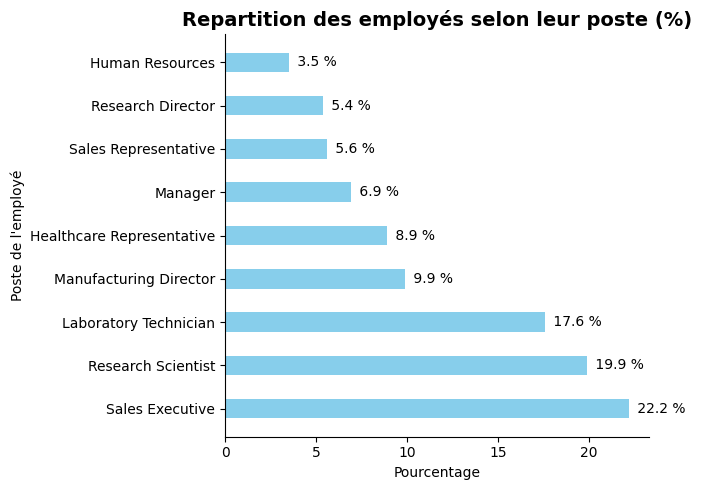

(None,)

In [26]:
fig , ax = plt.subplots(figsize=(7,5))

ax.spines['top'].set_visible(False)
ax.spines["right"].set_visible(False)

# Données
x = np.arange(len(jobRole_count["JobRole"]))
y = jobRole_count["Pourcentage"]

# Barplot
barhs = ax.barh(x, y, height=0.45, color="skyblue")
# Pourcentage affiché
ax.bar_label(barhs, labels=[f'{v : .1F} %' for v in y ], padding=3)

# axes et labels
ax.set_yticks(x)
ax.set_yticklabels(jobRole_count["JobRole"])
ax.set_xlabel("Pourcentage")
ax.set_ylabel("Poste de l'employé")
ax.set_title("Repartition des employés selon leur poste (%)", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show(),


##### 1.4.1.3 Le niveau hiérachiques (Joblevel)

##### Tableau des proportions

In [37]:
jobLevel_count = value_counts_percent(df_conditions_travail["JobLevel"])
jobLevel_count

,JobLevel,Pourcentage
0,Niveau hiérarchique bas,36.9
1,Niveau hiérarchique intermédiaire,36.3
2,Niveau hiérarchique confirmé,14.8
3,Niveau hiérarchique senior,7.2
4,Niveau hiérarchique très senior,4.7


On observe que la majorité des employés occupent un **niveau hiérarchique bas** ou **intermédiaire** (≈70 %).  
À l’inverse, les employés ayant un **niveau hiérarchique très senior** représentent environ **5 %** de l’effectif.

##### 1.4.1.5 Les déplacements professionelles (BusinessTravel)

##### Tableau des proportions

In [50]:
businesstravel_count = value_counts_percent(df_conditions_travail["BusinessTravel"])
businesstravel_count

,BusinessTravel,Pourcentage
0,Travel_Rarely,71.0
1,Travel_Frequently,18.8
2,Non-Travel,10.2


On observe qu’une large majorité des employés déclarent **voyager rarement pour des raisons professionnelles** (≈71 %).  
À l’inverse, environ **10 %** des salariés déclarent ne **jamais effectuer de déplacements professionnels**.

##### 1.4.1.5 Les heures Supplémentaires (Overtime)

##### Tableau des proportions

In [38]:
overtime_count = value_counts_percent(df_conditions_travail["OverTime"])
overtime_count

,OverTime,Pourcentage
0,No,71.7
1,Yes,28.3


###### Répartitions des employés en fonctions des heures supplémentaires.

On observe qu’une majorité des employés (**environ 72 %**) déclarent effectuer des heures supplémentaires au sein de l’entreprise.

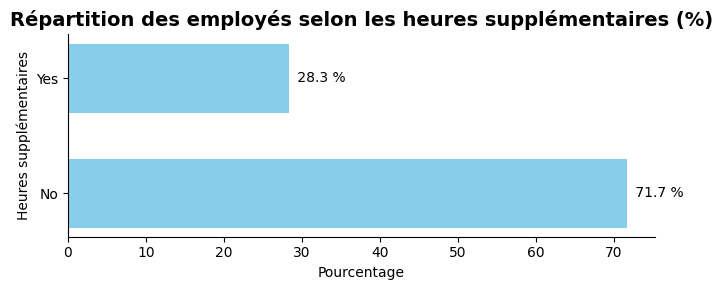

(None,)

In [48]:
fig, ax = plt.subplots(figsize=(7,3))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# données
x= np.arange(len(overtime_count.index))
y = overtime_count["Pourcentage"]

# barplot
barhs = ax.barh(x, y, height=0.6, color="skyblue")

# Pourcentage affiché
ax.bar_label(barhs, labels=[f'{v : .1F} %' for v in y], padding=3)

# axes et labels
ax.set_yticks(x)
ax.set_yticklabels(overtime_count["OverTime"])


ax.set_xlabel("Pourcentage")
ax.set_ylabel("Heures supplémentaires")
ax.set_title("Répartition des employés selon les heures supplémentaires (%)", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show(),

**FAIRE MINI SYNTHESE**

Après avoir décrit la structure des postes au sein de l’entreprise, l’analyse se poursuit avec les variables liées à la rémunération, afin de caractériser les niveaux de revenus et les éléments financiers associés aux conditions de travail.

#### 1.4.2 Rémunération
---
Cette section s’intéresse aux variables liées à la **rémunération et aux éléments financiers associés**.

Les variables analysées sont :

- **MonthlyIncome** : correspond au revenu mensuel de l’employé.
- **PercentSalaryHike** : indique le pourcentage d’augmentation de salaire.
- **StockOptionLevel** : représente le niveau d’options d’actions attribuées à l’employé.
 
Ces variables sont analysées de manière descriptive afin de caractériser la distribution des niveaux de rémunération au sein de l’entreprise.

##### 1.4.2.1 Le revenu mensuel de l'employé (MonthlyIncome)

##### Tableau des proportions

In [83]:
MonthlyIncome_count = value_counts_percent(df_conditions_travail["Tranche_Salaire"])
MonthlyIncome_count 


,Tranche_Salaire,Pourcentage
0,2 500 - 5 000,35.6
1,> 7 500,28.0
2,5 000 - 7 500,21.1
3,< 2 500,15.4


##### Répartitions des employés en fonctions de leur revenu mensuel.

Ce graphique montre que deux tranches de revenu sont particulièrement représentées :
- la tranche **2 500 – 5 000** (≈36 %),
- la tranche **> 7 500** (≈28 %).

Les tranches plus minoritaires sont **5 000 – 7 500** (≈21 %) et **< 2 500** (≈15 %).

Cette exploration met en évidence les grandes lignes de l’échelle salariale et permet d’apprécier la diversité des profils de rémunération au sein de l’entreprise.


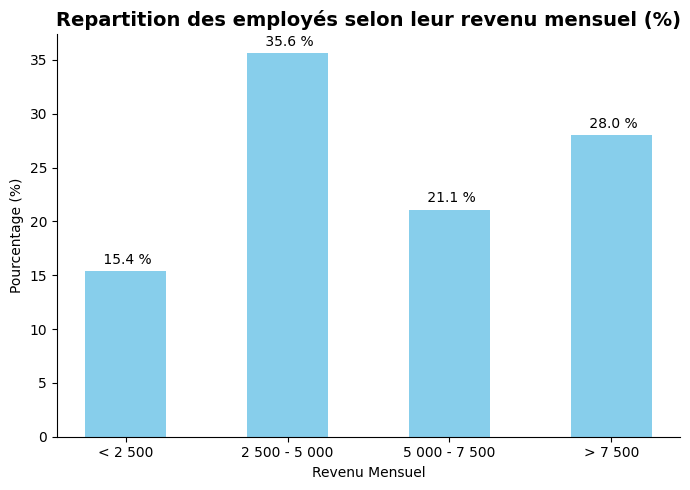

(None,)

In [107]:
MonthlyIncome_count = MonthlyIncome_count.sort_values("Tranche_Salaire", ascending=True)

fig, ax = plt.subplots(figsize=(7,5))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Données
x = np.arange(len(MonthlyIncome_count.index))
y = MonthlyIncome_count["Pourcentage"]

# Barplot
barhs = ax.bar(x, y, width=0.5, color="skyblue")

# Pourcentage
ax.bar_label(barhs, labels=[f"{v : .1F} %" for v in y], padding=3)

# Axes et labels
ax.set_xticks(x)
ax.set_xticklabels(MonthlyIncome_count["Tranche_Salaire"])
ax.set_xlabel("Revenu Mensuel")
ax.set_ylabel("Pourcentage (%)")
ax.set_title("Repartition des employés selon leur revenu mensuel (%)", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show(),

##### 1.4.2.2 Le pourcentage d’augmentation de salaire de l'employé (PercentSalaryHike)

##### Tableau des proportions

In [110]:
PercentSalaryHike_count = value_counts_percent(df_conditions_travail["Tranche_PercentSalaryHike"])
PercentSalaryHike_count

,Tranche_PercentSalaryHike,Pourcentage
0,12-15,34.8
1,< 12,27.8
2,> 18,20.5
3,15-18,16.9


##### Répartition des employés selon leur pourcentage d’augmentation de salaire

Ce graphique montre que deux tranches sont particulièrement représentées :
- la tranche **12–15 %** d’augmentation de salaire (≈35 %),
- la tranche **< 12 %** (≈28 %).

Les tranches plus minoritaires sont **> 18 %** (≈21 %) et **15–18 %** (≈17 %).

Cette exploration permet d’avoir une première vision des niveaux d’augmentation de salaire au sein de l’entreprise.


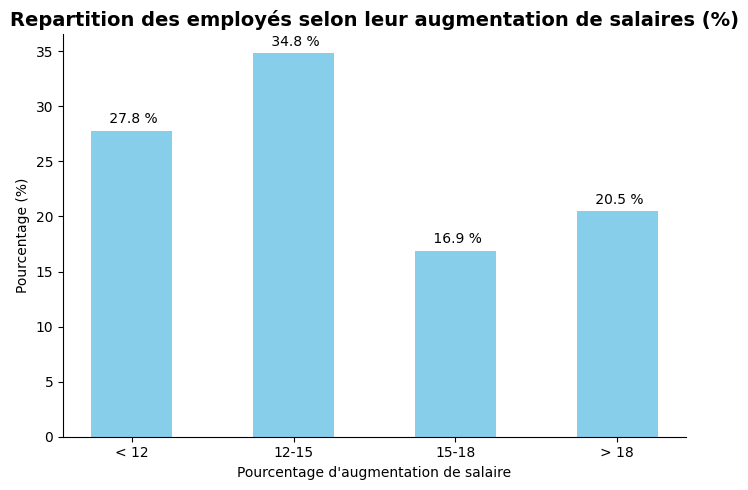

(None,)

In [109]:
PercentSalaryHike_count = PercentSalaryHike_count.sort_values("Tranche_PercentSalaryHike", ascending=True)

fig, ax = plt.subplots(figsize=(7,5))


ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Données
x = np.arange(len(PercentSalaryHike_count.index))
y = PercentSalaryHike_count["Pourcentage"]

# Barplot
barhs = ax.bar(x, y, width=0.5, color="skyblue")

# Pourcentage
ax.bar_label(barhs, labels=[f"{v : .1F} %" for v in y], padding=3)

# Axes et labels
ax.set_xticks(x)
ax.set_xticklabels(PercentSalaryHike_count["Tranche_PercentSalaryHike"])
ax.set_xlabel("Pourcentage d'augmentation de salaire")
ax.set_ylabel("Pourcentage (%)")
ax.set_title("Repartition des employés selon leur augmentation de salaires (%)", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show(),

##### 1.4.2.3 Le niveau de stock-option attribué à l'employé (StockOptionLevel)

##### Tableau des proportions

In [106]:
stockOptionLevel_count = value_counts_percent(df_conditions_travail["StockOptionLevel"])
stockOptionLevel_count

,StockOptionLevel,Pourcentage
0,Aucun,42.9
1,Niveau 1,40.5
2,Niveau 2,10.7
3,Niveau 3,5.8


On observe que la majorité des employés ne bénéficient **d’aucune stock-option** ou disposent d’un **niveau 1 de stock-options** (≈83 %).  

À l’inverse, les employés ayant un **niveau 3 de stock-options** représentent environ **6 %** de l’effectif.

Cette exploration met en évidence les grandes lignes d’un élément de rémunération variable attribué à une partie limitée des salariés.

#### 1.4.3 Ancienneté et carrière
---
Cette section porte sur les variables décrivant l’**ancienneté** et le **parcours professionnel** des employés.

Les variables étudiées sont :

- **YearsAtCompany** : représente le nombre d’années passées par l’employé dans l’entreprise.
- **YearsInCurrentRole** : correspond à l’ancienneté dans le poste actuel.
- **TotalWorkingYears** : indique le nombre total d’années d’expérience professionnelle.

L’analyse de ces variables permet de décrire le niveau d’expérience et l’ancienneté des employés au sein de l’organisation.


##### Tableau des proportions

##### Répartition des employés 


#### 1.4.4 Management et évolution
---

Cette dernière section explore les variables relatives au **management** et aux **aspects de l’évolution professionnelle**

Les variables analysées sont :

- **YearsSinceLastPromotion** : indique le nombre d’années écoulées depuis la dernière promotion de l’employé.
- **TrainingTimesLastYear** : correspond au nombre de formations suivies au cours de l’année précédente.
- **YearsWithCurrManager** : représente la durée de collaboration avec le manager actuel.

Ces variables sont décrites afin de mieux caractériser le contexte managérial et les parcours d’évolution au sein de l’entreprise.

##### Tableau des proportions

##### Repartitions des employes par 


## 2. Attrition — Comparaisons simples
---

### 2.1 Introduction
---
Dans cette section, je compare la variable cible, l’attrition, aux variables des conditions de travails analysées précédemment, afin d’identifier d’éventuelles relations entre ces caractéristiques et le départ des employés.


##### Tableau de proportions Attrition Yes / No

In [55]:
attrition = df_conditions_travail['Attrition'].value_counts(normalize=True).sort_values(ascending=False).round(3)*100

df_attrition = attrition.reset_index()
df_attrition.columns = ['Attrition', "Pourcentage"]

df_attrition

,Attrition,Pourcentage
0,No,83.9
1,Yes,16.1


D’après ce tableau, le taux d’attrition global observé dans le jeu de données est d’environ **16 %**, ce qui constitue le niveau de référence pour les analyses suivantes.
Dans les analyses suivantes, l’accent est mis sur le taux d’attrition (Attrition = Yes), les non-départs représentant le complément à 100 %.

### 2.2 Analyse de l’attrition selon les variables des conditions de travail
---
Certaines variables des conditions de travail ont été explorées individuellement mais n’ont pas été approfondies dans l’analyse de l’attrition en raison d’une distribution peu différenciante ou d’un impact limité observé lors de l’exploration initiale.

Les variables sont comparées à partir de leur fréquence, à l’aide de tableaux de proportions et de visualisations graphiques.  
Cette approche permet d’identifier des différences de comportement entre les groupes avant toute analyse approfondie.

#### 2.2.1 Attrition et Department
---

##### Tableau de proportions ­­

##### Graphique — Analyse de la relation entre 

##### Observation descriptive

#### 2.2.2 Attrition et JobRole
---


##### Tableau de proportions

##### Graphique — Analyse de la relation 

##### Observation descriptive

#### 2.2.3 Attrition et MonthlyIncome
---


##### Tableau de proportions

##### Graphique — Analyse de la relation entre 

##### Observation descriptive

#### 2.2.4 Attrition et overtime
---

##### Tableau de proportions

##### Graphique — Analyse de la relation entre 

##### Observation descriptive

#### 2.2.5 Attrition et TotalWorkingYears
---

##### Tableau de proportions

##### Graphique — Analyse de la relation entre 

##### Observation descriptive 

#### 2.2.6 Attrition et TrainingTimesLastYear
---

##### Tableau de proportions

##### Graphique — Analyse de la relation entre 

##### Observation descriptive 

#### 2.2.7 Attrition et YearsAtCompany
---

##### Tableau de proportions

##### Graphique — Analyse de la relation entre 

##### Observation descriptive 

#### 2.2.8 Attrition et YearsInCurrentRole
---

##### Tableau de proportions

##### Graphique — Analyse de la relation entre 

##### Observation descriptive 

#### 2.2.9 Attrition et YearsSinceLastPromotion
---

##### Tableau de proportions

##### Graphique — Analyse de la relation entre 

##### Observation descriptive 

#### 2.2.14 Attrition et YearsWithCurrManager
---

##### Tableau de proportions

##### Graphique — Analyse de la relation entre 

##### Observation descriptive 

Une fois les comparaisons simples réalisées, j’explore les relations internes à l’axe afin d’identifier d’éventuels patterns ou corrélations.

## 3. Relations internes à l’axe condition de travail
----

### 3.1 Introduction

Après avoir analysé les relations entre les variables personnelles et l’attrition, cette section vise à explorer les relations internes entre les variables de l’axe *Condition de travail*, afin d’identifier d’éventuels patterns ou profils récurrents.  
Les variables sont analysées à partir de tableaux croisés et de visualisations graphiques descriptives.

---


### 3.2 Analyse des relations entre variables organisationnelles

#### 3.2.1 Relation entre 
---

##### Tableaux croisés

##### Visualisation

##### Observations descriptives



#### 3.2.2 Relation entre 
---


##### Tableaux croisés

##### Visualisation

##### Observations descriptives


#### 3.2.3 Relation entre 
---


##### Tableau croisé

##### Visualisation

##### Observations descriptives



Après avoir analysé ces trois relations, cette section synthétise les principaux patterns observés.

### 3.3 Synthèse des patterns observés
---
Les analyses des relations internes à l’axe *Condition de travail* mettent en évidence plusieurs patterns structurants :

- **Pattern 1 — Relation entre**  
  
- **Pattern 2 — Relation entre**  
  
- **Pattern 3 — Relation entre**  
  
  Ces patterns permettent de mieux contextualiser les résultats observés précédemment et servent de base à la synthèse globale de l’axe Condition de travail.
  ---

# 4. Résultats clés 
---


---

# 5. Conclusion de l’axe “Condition de travail”
---

